In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

iris=load_iris()

# iris.data
# iris.target
# iris.feature_names
# iris.target_names   

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

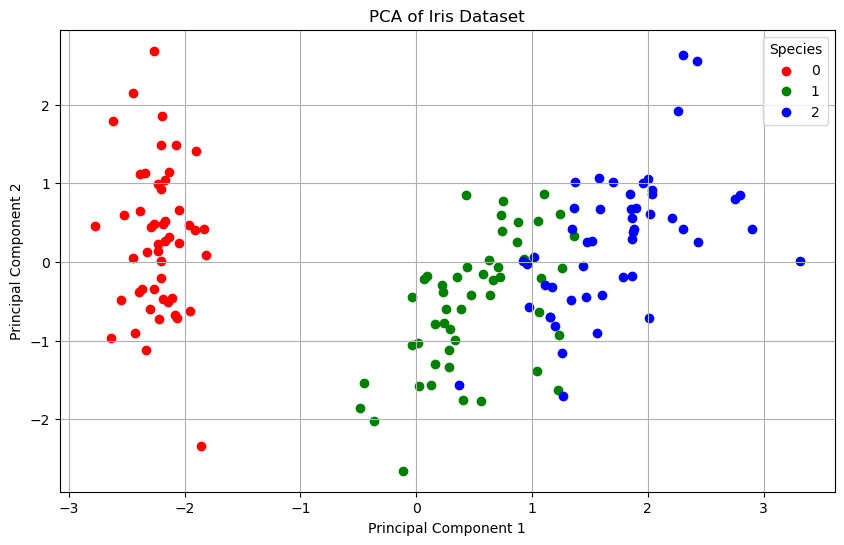

In [24]:
features=iris.data
target=iris.target

features.shape
target.shape
scaler=StandardScaler()
scaled_features=scaler.fit_transform(features)

scaled_features.shape

pca=PCA(n_components=2)
features_pca=pca.fit_transform(scaled_features)

features_pca.shape

pca_df=pd.DataFrame(data=features_pca,columns=["pc1","pc2"])
pca_df.head()

pca_df["target"]=target

plt.figure(figsize=(10,6))

for label,color in zip(np.unique(pca_df["target"]),["red","green","blue"]):
    plt.scatter(
        pca_df.loc[pca_df["target"]==label,"pc1"],
        pca_df.loc[pca_df["target"]==label,"pc2"],
        label=label,
        color=color
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Iris Dataset")
plt.legend(title="Species")
plt.grid()
plt.show()


In [27]:
explained_variance=pca.explained_variance_ratio_

print("Explained varaince by each pc")
print("PC1:",explained_variance[0])
print("PC2:",explained_variance[1])
print("Total Explained Variance:",explained_variance.sum())

Explained varaince by each pc
PC1: 0.7296244541329988
PC2: 0.22850761786701748
Total Explained Variance: 0.9581320720000163


In [28]:
iris_df=pd.DataFrame(data=iris.data,columns=iris.feature_names)
iris_df['species']=iris.target

print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


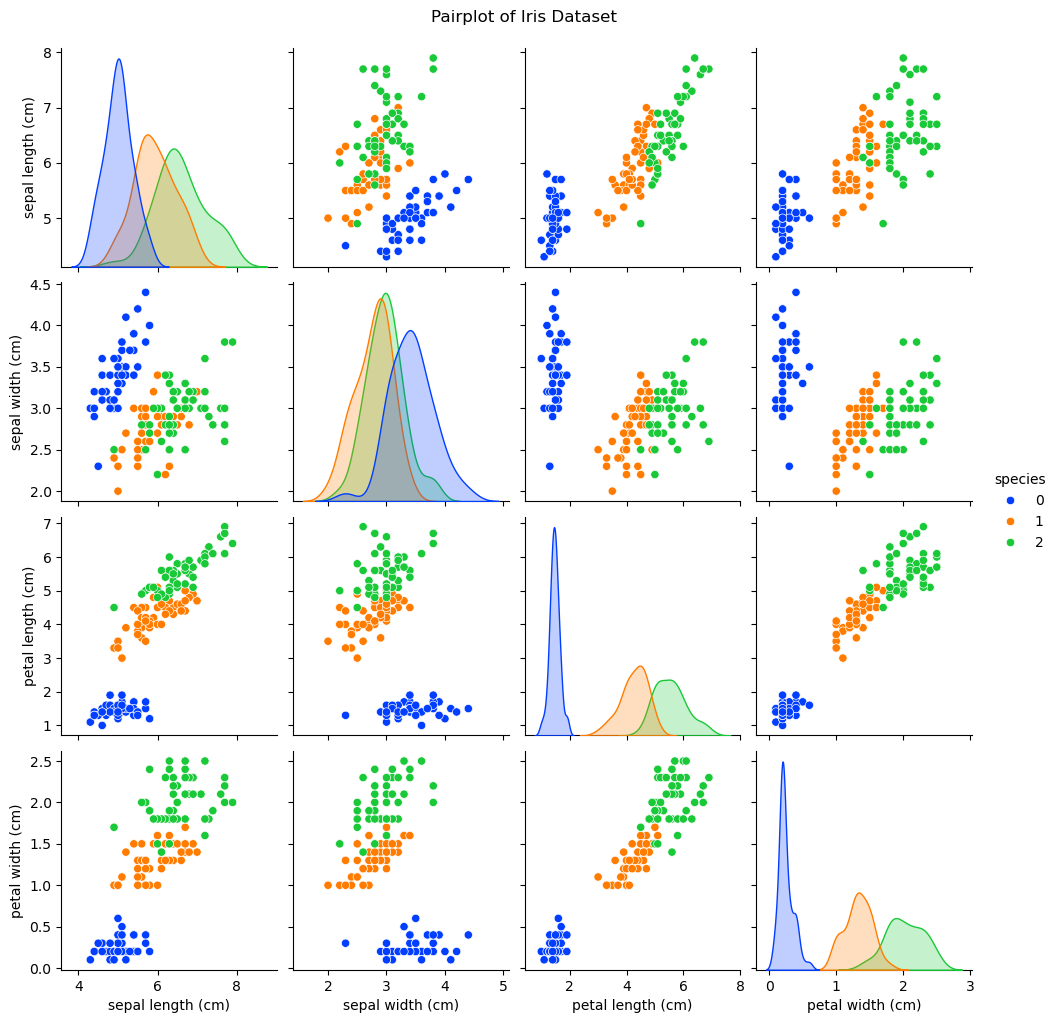

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(iris_df,hue='species',palette='bright')
plt.suptitle('Pairplot of Iris Dataset',y=1.02)
plt.show()